In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features, make_lags_dataset
from utils.exp_handler import load_exp
import pandas as pd

# Загружаем тестовый пример
test_example = pd.read_excel('test_example.xlsx')
vat_num = test_example['vat_num']
target = test_example['target']
print(f'Контрагент {vat_num.item()}')
print(f'Реальный показатель дефолта: {target.item()}')

# Убираем лишнее перед подачей данных в модель
test_example_to_model = test_example.drop(columns=['vat_num', 'year', 'target', 'dflt_year'], errors='ignore')

# Загружаем модель
loaded_big = load_exp('exp/big_df_no_lags')

# Делаем прогноз
proba = loaded_big['calibrated_model'].predict_proba(test_example_to_model)[0][1]
print(f'Предсказанная вероятность дефолта: {proba:.3}')

Контрагент 273081859
Реальный показатель дефолта: 1


c:\py\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\py\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator CalibratedClassifierCV from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


AttributeError: The following error was raised: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

Predicted calibrated probability: 0.14285714285714285


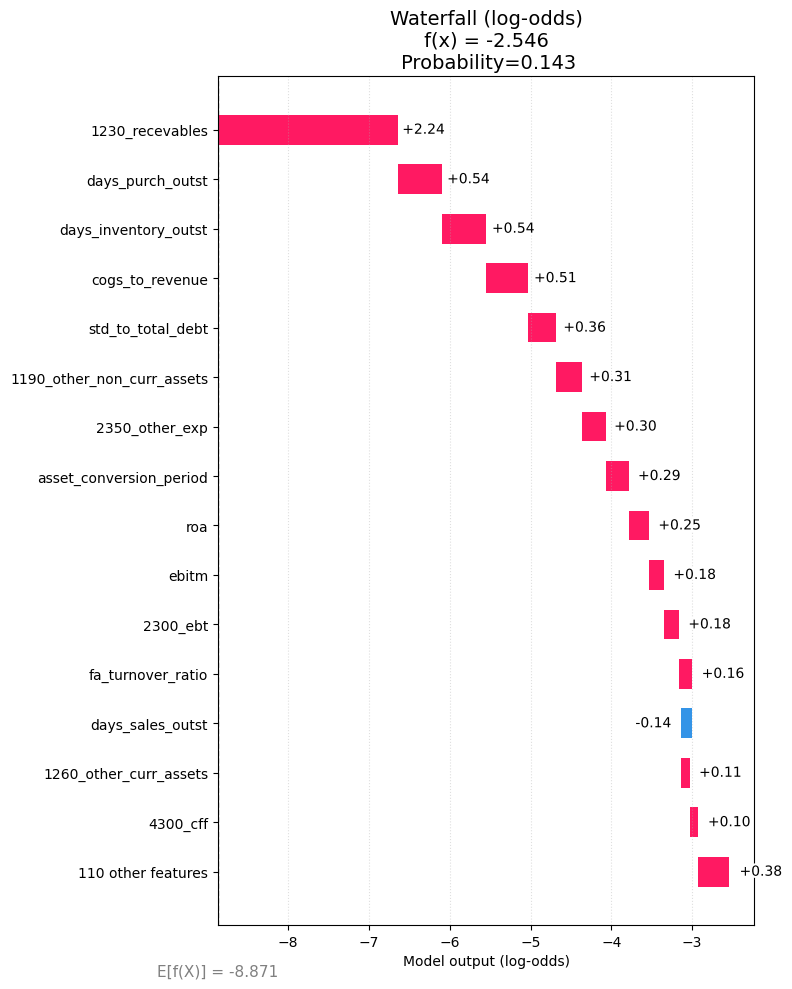

In [ ]:
from utils.waterfall_graph import show_waterfall_graph
show_waterfall_graph(loaded_big['model'], loaded_big['calibrated_model'], test_example)